# Hito 3 - Pipeline de Preprocesamiento y Ajuste de Hiperparametros
## GuardianAI - Deteccion Inteligente de Fraude Bancario

## Indice

1. Importacion de librerias
2. Carga y particion de datos (70/15/15)
3. Pipeline de preprocesamiento con SMOTE
   - 3.1. Codificacion de variables categoricas
   - 3.2. Escalado de variables numericas
   - 3.3. Aplicacion de SMOTE
4. Modelo XGBoost base (con preprocesado)
5. Busqueda de hiperparametros optimos
   - 5.1. Espacio de busqueda y justificacion
   - 5.2. RandomizedSearchCV
6. Modelo XGBoost optimizado
7. Comparativa: base vs optimizado
8. Importancia de caracteristicas
9. Evaluacion final sobre el conjunto de test real

## 1. Importacion de librerias

In [1]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    roc_curve, precision_recall_curve, auc,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

os.makedirs('../figures', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

## 2. Carga y particion de datos (70/15/15)

En NB02 se usaba una particion 80/20 adecuada para la comparativa de modelos. En esta fase de optimizacion se cambia a **70/15/15** para disponer de tres conjuntos con roles distintos:

- **Train (70%)**: datos sobre los que se aplica SMOTE y se entrena el modelo.
- **Validacion (15%)**: datos que el modelo no ve durante el entrenamiento, usados internamente por `RandomizedSearchCV` para evaluar cada combinacion de hiperparametros durante la busqueda.
- **Test (15%)**: datos apartados desde el principio que no participan en ningun paso del entrenamiento ni de la busqueda. Representan las condiciones reales de operacion con el desbalanceo original (~1.1% de fraudes). **Las metricas finales se calculan exclusivamente sobre este conjunto.**

> Es importante no evaluar nunca el modelo sobre los datos de entrenamiento ni sobre los datos balanceados por SMOTE: esos datos son artificialmente perfectos para el modelo y producen metricas infladas que no reflejan el rendimiento real.

In [2]:
# Carga del dataset
df = pd.read_csv('Base.csv')
df = df.drop(columns=['credit_risk_score'])  # data leakage

X = df.drop(columns=['fraud_bool'])
y = df['fraud_bool']

# Primera particion: 70% train, 30% temporal
X_train_70, X_temp, y_train_70, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Segunda particion: 50% del temporal = 15% val, 15% test
X_val_15, X_test_15, y_val_15, y_test_15 = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print('Tamanos de cada particion:')
print(f'  Train:      {len(X_train_70):,} registros  '
      f'(fraude: {y_train_70.mean()*100:.2f}%)')
print(f'  Validacion: {len(X_val_15):,} registros  '
      f'(fraude: {y_val_15.mean()*100:.2f}%)')
print(f'  Test:       {len(X_test_15):,} registros  '
      f'(fraude: {y_test_15.mean()*100:.2f}%)')

Tamanos de cada particion:
  Train:      700,000 registros  (fraude: 1.10%)
  Validacion: 150,000 registros  (fraude: 1.10%)
  Test:       150,000 registros  (fraude: 1.10%)


## 3. Pipeline de preprocesamiento con SMOTE

El preprocesamiento se aplica **unicamente al conjunto de train**, siguiendo este orden:

1. Codificacion de variables categoricas (one-hot encoding).
2. Escalado de variables numericas con `StandardScaler` (ajustado solo sobre train, aplicado a val y test).
3. SMOTE sobre los datos de train ya codificados y escalados.

El conjunto de validacion y el de test **no se tocan con SMOTE**: deben mantener el desbalanceo original para que la evaluacion sea realista.

### 3.1. Codificacion de variables categoricas

`pd.get_dummies` convierte cada categoria en una columna binaria (0/1). Se ajusta sobre el conjunto de train y se alinean val y test para que tengan exactamente las mismas columnas.

In [3]:
# Codificacion one-hot de variables categoricas
X_train_enc = pd.get_dummies(X_train_70, drop_first=True)
X_val_enc   = pd.get_dummies(X_val_15,   drop_first=True)
X_test_enc  = pd.get_dummies(X_test_15,  drop_first=True)

# Alinear columnas: val y test deben tener las mismas que train
# (puede haber categorias que no aparezcan en val/test)
X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns,  fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f'Columnas tras one-hot encoding: {X_train_enc.shape[1]}')

Columnas tras one-hot encoding: 46


### 3.2. Escalado de variables numericas

`StandardScaler` resta la media y divide entre la desviacion tipica, dejando cada variable con media 0 y desviacion tipica 1. Esto es necesario para que variables con rangos muy distintos (por ejemplo `velocity_6h` con rango [-175, 16818] frente a `income` con rango [0.1, 0.9]) no dominen el aprendizaje.

**Importante**: el scaler se ajusta (`fit`) solo sobre los datos de train. Aplicarlo sobre val o test antes de ajustarlo seria fuga de datos: el modelo estaria usando informacion estadistica del futuro.

In [4]:
# Identificar columnas numericas del train codificado
numeric_cols = X_train_enc.select_dtypes(include='number').columns.tolist()

# Ajustar el scaler solo con los datos de entrenamiento
scaler = StandardScaler()
scaler.fit(X_train_enc[numeric_cols])

# Aplicar la misma transformacion a train, val y test
X_train_enc[numeric_cols] = scaler.transform(X_train_enc[numeric_cols])
X_val_enc[numeric_cols]   = scaler.transform(X_val_enc[numeric_cols])
X_test_enc[numeric_cols]  = scaler.transform(X_test_enc[numeric_cols])

print('Escalado aplicado correctamente.')
print(f'  Train: {X_train_enc.shape}  '
      f'Val: {X_val_enc.shape}  '
      f'Test: {X_test_enc.shape}')

Escalado aplicado correctamente.
  Train: (700000, 46)  Val: (150000, 46)  Test: (150000, 46)


### 3.3. Aplicacion de SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) genera muestras sinteticas de la clase minoritaria (fraude) para equilibrar el dataset de entrenamiento.

**Como funciona**: para cada muestra de fraude real, busca sus k vecinos mas proximos (k=5 por defecto) en el espacio de features y crea nuevas muestras interpolando aleatoriamente entre esa muestra y sus vecinos. No duplica muestras existentes, sino que crea variantes nuevas y plausibles.

**Por que despues del escalado**: SMOTE mide distancias entre muestras para encontrar vecinos proximos. Si las variables no estan en la misma escala, las de mayor rango dominan el calculo de distancias y los vecinos encontrados no son representativos. El escalado previo garantiza que todas las variables contribuyen por igual.

**Resultado esperado**: el conjunto de train pasa de ~1.1% de fraudes a 50%, con aproximadamente el doble de muestras totales.

> SMOTE se aplica **solo al conjunto de train**. Val y test conservan el desbalanceo original para que la evaluacion sea realista.

In [5]:
print(f'Antes de SMOTE:')
print(f'  Muestras train: {len(X_train_enc):,}')
print(f'  Fraudes en train: {y_train_70.sum():,} ({y_train_70.mean()*100:.2f}%)')

# Aplicar SMOTE al conjunto de entrenamiento
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train_70)

print(f'\nDespues de SMOTE:')
print(f'  Muestras train: {len(X_train_smote):,}')
print(f'  Fraudes en train: {y_train_smote.sum():,} ({y_train_smote.mean()*100:.2f}%)')
print(f'  Muestras sinteticas generadas: {len(X_train_smote) - len(X_train_enc):,}')

Antes de SMOTE:
  Muestras train: 700,000
  Fraudes en train: 7,720 (1.10%)

Despues de SMOTE:
  Muestras train: 1,384,560
  Fraudes en train: 692,280 (50.00%)
  Muestras sinteticas generadas: 684,560


## 4. Modelo XGBoost base (con preprocesado)

Se entrena un XGBoost con hiperparametros iniciales razonables sobre los datos balanceados por SMOTE. Este modelo sirve como punto de partida antes de la busqueda de hiperparametros: establece una linea de referencia con la que comparar la mejora obtenida en la seccion 7.

**Nota critica**: las metricas se calculan sobre el **conjunto de test** (datos originales con desbalanceo real), no sobre los datos de train. Evaluar sobre el train produciria metricas artificialmente perfectas porque el modelo ya los ha visto — y aun mas si esos datos estan balanceados por SMOTE.

In [6]:
# Modelo XGBoost con parametros iniciales
xgb_base = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    min_child_weight=1,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

t0 = time.time()
xgb_base.fit(X_train_smote, y_train_smote)
tiempo_base = time.time() - t0

# Predicciones sobre el conjunto de TEST (desbalanceo real)
y_prob_base = xgb_base.predict_proba(X_test_enc)[:, 1]

# Umbral optimo: el que maximiza F1 en test
best_thr = 0.5
best_f1  = 0.0
for thr in np.arange(0.05, 0.95, 0.01):
    y_pred_thr = (y_prob_base >= thr).astype(int)
    score = f1_score(y_test_15, y_pred_thr, zero_division=0)
    if score > best_f1:
        best_f1  = score
        best_thr = thr

y_pred_base = (y_prob_base >= best_thr).astype(int)

# Metricas finales sobre el test REAL
prec_base   = precision_score(y_test_15, y_pred_base, zero_division=0)
rec_base    = recall_score(y_test_15, y_pred_base, zero_division=0)
f1_base     = f1_score(y_test_15, y_pred_base, zero_division=0)
prauc_base  = average_precision_score(y_test_15, y_prob_base)
rocauc_base = roc_auc_score(y_test_15, y_prob_base)

print('Modelo XGBoost base — evaluado sobre el test real (desbalanceado)')
print(f'  Tiempo de entrenamiento: {tiempo_base:.1f}s')
print(f'  Umbral optimo (F1 max):  {best_thr:.2f}')
print(f'  Precision:  {prec_base:.4f}')
print(f'  Recall:     {rec_base:.4f}')
print(f'  F1-Score:   {f1_base:.4f}')
print(f'  PR-AUC:     {prauc_base:.4f}')
print(f'  ROC-AUC:    {rocauc_base:.4f}')

Modelo XGBoost base — evaluado sobre el test real (desbalanceado)
  Tiempo de entrenamiento: 10.0s
  Umbral optimo (F1 max):  0.23
  Precision:  0.1445
  Recall:     0.2793
  F1-Score:   0.1905
  PR-AUC:     0.1142
  ROC-AUC:    0.8679


## 5. Busqueda de hiperparametros optimos

### 5.1. Espacio de busqueda y justificacion

Se exploran 8 hiperparametros de XGBoost. A continuacion se justifica cada rango elegido y por que ese hiperparametro importa:

| Hiperparametro | Rango | Por que ese rango |
|----------------|-------|-------------------|
| `n_estimators` | [100, 300] | Menos de 100 suele ser insuficiente para datasets grandes; mas de 300 con early stopping no aporta mejora y ralentiza |
| `max_depth` | [4, 9] | Arboles muy superficiales (< 4) no capturan interacciones; muy profundos (> 9) memorizan el training set |
| `learning_rate` | [0.01, 0.2] | Rango clasico de la literatura; valores fuera de este rango o convergen demasiado lento (< 0.01) o demasiado agresivo (> 0.3) |
| `subsample` | [0.6, 1.0] | Por debajo de 0.6 se pierde demasiada informacion por muestra; 1.0 desactiva la aleatoriedad |
| `colsample_bytree` | [0.6, 1.0] | Igual que subsample pero para columnas |
| `min_child_weight` | [1, 5] | Controla el minimo de muestras en una hoja; valores altos dan mas regularizacion |
| `reg_alpha` | [0.0, 2.0] | Regularizacion L1; 0 la desactiva, valores mayores penalizan features con coeficientes pequenos |
| `reg_lambda` | [0.0, 2.0] | Regularizacion L2; similar a L1 pero penaliza el cuadrado de los coeficientes |

**Por que RandomizedSearchCV y no GridSearchCV**: con 8 hiperparametros y los rangos indicados existirian miles de combinaciones posibles. GridSearchCV las probaría todas, lo que tardaria horas. RandomizedSearchCV prueba 50 combinaciones elegidas al azar del espacio de busqueda, lo que cubre una muestra representativa del espacio en un tiempo razonable. La literatura muestra que 50-100 iteraciones aleatorias suelen encontrar soluciones comparables al grid exhaustivo.

### 5.2. RandomizedSearchCV con validacion cruzada 5-fold

La validacion cruzada 5-fold divide el conjunto de entrenamiento en 5 partes iguales. Para cada combinacion de hiperparametros, entrena el modelo 5 veces usando 4 partes como train y 1 como validacion, rotando cual parte actua de validacion. El resultado es la media de las 5 puntuaciones, lo que da una estimacion mas estable que una sola particion train/val.

La metrica de optimizacion es **ROC-AUC** porque es diferenciable y estable durante la busqueda. Las metricas finales se evaluaran en la seccion 9 sobre el conjunto de test real.

In [8]:
# Espacio de hiperparametros a explorar
param_dist = {
    'n_estimators'    : [100, 150, 200, 250, 300],
    'max_depth'       : [4, 5, 6, 7, 8, 9],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 4, 5],
    'reg_alpha'       : [0.0, 0.5, 1.0, 1.5, 2.0],
    'reg_lambda'      : [0.0, 0.5, 1.0, 1.5, 2.0],
}

# Modelo base para la busqueda
xgb_para_busqueda = XGBClassifier(
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

# Busqueda aleatoria con validacion cruzada 5-fold
busqueda = RandomizedSearchCV(
    estimator=xgb_para_busqueda,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    refit=True,
    n_jobs=4,
    verbose=1,
    random_state=42
)

print('Iniciando busqueda de hiperparametros...')
print('  50 combinaciones x 5 folds = 250 entrenamientos en total')

t0 = time.time()
busqueda.fit(X_train_smote, y_train_smote)
tiempo_busqueda = time.time() - t0

print(f'\nBusqueda completada en {tiempo_busqueda/60:.1f} minutos')
print(f'\nMejores hiperparametros encontrados:')
for nombre, valor in busqueda.best_params_.items():
    print(f'  {nombre}: {valor}')

# Estabilidad de la busqueda: desviacion tipica del mejor resultado
mejor_idx = busqueda.best_index_
media_cv  = busqueda.cv_results_['mean_test_score'][mejor_idx]
std_cv    = busqueda.cv_results_['std_test_score'][mejor_idx]
print(f'\nROC-AUC en validacion cruzada: {media_cv:.4f} +/- {std_cv:.4f}')
print('(desviacion tipica baja indica que el resultado es estable entre folds)')

Iniciando busqueda de hiperparametros...
  50 combinaciones x 5 folds = 250 entrenamientos en total
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Busqueda completada en 31.2 minutos

Mejores hiperparametros encontrados:
  subsample: 1.0
  reg_lambda: 0.0
  reg_alpha: 0.5
  n_estimators: 250
  min_child_weight: 1
  max_depth: 9
  learning_rate: 0.2
  colsample_bytree: 0.7

ROC-AUC en validacion cruzada: 0.9988 +/- 0.0024
(desviacion tipica baja indica que el resultado es estable entre folds)


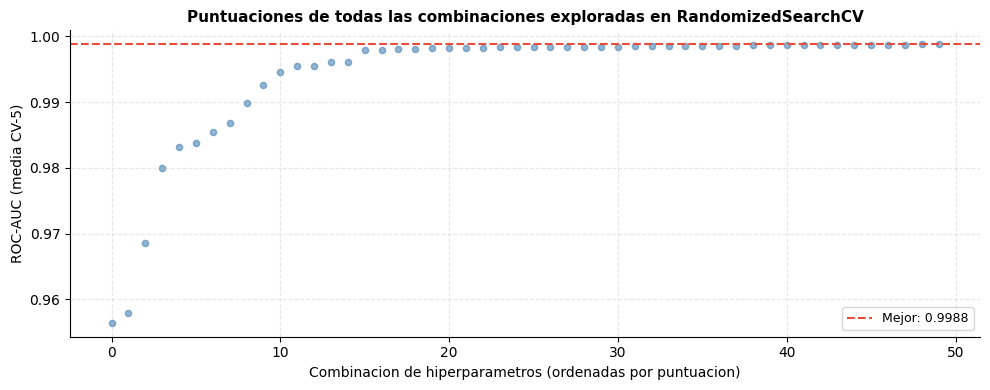

In [9]:
# Visualizar la distribucion de puntuaciones de todas las combinaciones exploradas
todas_puntuaciones = busqueda.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(todas_puntuaciones)), sorted(todas_puntuaciones),
           color='steelblue', s=20, alpha=0.6)
ax.axhline(media_cv, color='#E74C3C', linestyle='--', lw=1.5,
           label=f'Mejor: {media_cv:.4f}')
ax.set_xlabel('Combinacion de hiperparametros (ordenadas por puntuacion)', fontsize=10)
ax.set_ylabel('ROC-AUC (media CV-5)', fontsize=10)
ax.set_title('Puntuaciones de todas las combinaciones exploradas en RandomizedSearchCV',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../figures/hyperparameter_search_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Modelo XGBoost optimizado

`RandomizedSearchCV` con `refit=True` ya ha entrenado internamente el modelo con los mejores hiperparametros sobre todos los datos de entrenamiento. Se extrae directamente ese modelo y se evalua sobre el test real.

In [10]:
# El mejor modelo ya esta entrenado dentro del objeto busqueda
xgb_optimizado = busqueda.best_estimator_

# Predicciones sobre el conjunto de TEST (desbalanceo real)
y_prob_opt = xgb_optimizado.predict_proba(X_test_enc)[:, 1]

# Umbral optimo para el modelo optimizado
best_thr_opt = 0.5
best_f1_opt  = 0.0
for thr in np.arange(0.05, 0.95, 0.01):
    y_pred_thr = (y_prob_opt >= thr).astype(int)
    score = f1_score(y_test_15, y_pred_thr, zero_division=0)
    if score > best_f1_opt:
        best_f1_opt  = score
        best_thr_opt = thr

y_pred_opt = (y_prob_opt >= best_thr_opt).astype(int)

# Metricas del modelo optimizado sobre el test REAL
prec_opt   = precision_score(y_test_15, y_pred_opt, zero_division=0)
rec_opt    = recall_score(y_test_15, y_pred_opt, zero_division=0)
f1_opt     = f1_score(y_test_15, y_pred_opt, zero_division=0)
prauc_opt  = average_precision_score(y_test_15, y_prob_opt)
rocauc_opt = roc_auc_score(y_test_15, y_prob_opt)

print('Modelo XGBoost optimizado — evaluado sobre el test real (desbalanceado)')
print(f'  Umbral optimo (F1 max):  {best_thr_opt:.2f}')
print(f'  Precision:  {prec_opt:.4f}')
print(f'  Recall:     {rec_opt:.4f}')
print(f'  F1-Score:   {f1_opt:.4f}')
print(f'  PR-AUC:     {prauc_opt:.4f}')
print(f'  ROC-AUC:    {rocauc_opt:.4f}')

Modelo XGBoost optimizado — evaluado sobre el test real (desbalanceado)
  Umbral optimo (F1 max):  0.12
  Precision:  0.1733
  Recall:     0.2557
  F1-Score:   0.2066
  PR-AUC:     0.1175
  ROC-AUC:    0.8777


## 7. Comparativa: base vs optimizado

Se comparan ambos modelos sobre el mismo conjunto de test real. Cualquier diferencia en las metricas se debe exclusivamente a la optimizacion de hiperparametros, no a diferencias en los datos.

Comparativa de modelos sobre el conjunto de test real:


,Metrica,Modelo base,Modelo optimizado,Diferencia,Mejora (%)
0,Precision,0.1445,0.1733,0.0288,19.91
1,Recall,0.2793,0.2557,-0.0236,-8.44
2,F1-Score,0.1905,0.2066,0.0161,8.46
3,PR-AUC,0.1142,0.1175,0.0033,2.88
4,ROC-AUC,0.8679,0.8777,0.0099,1.14


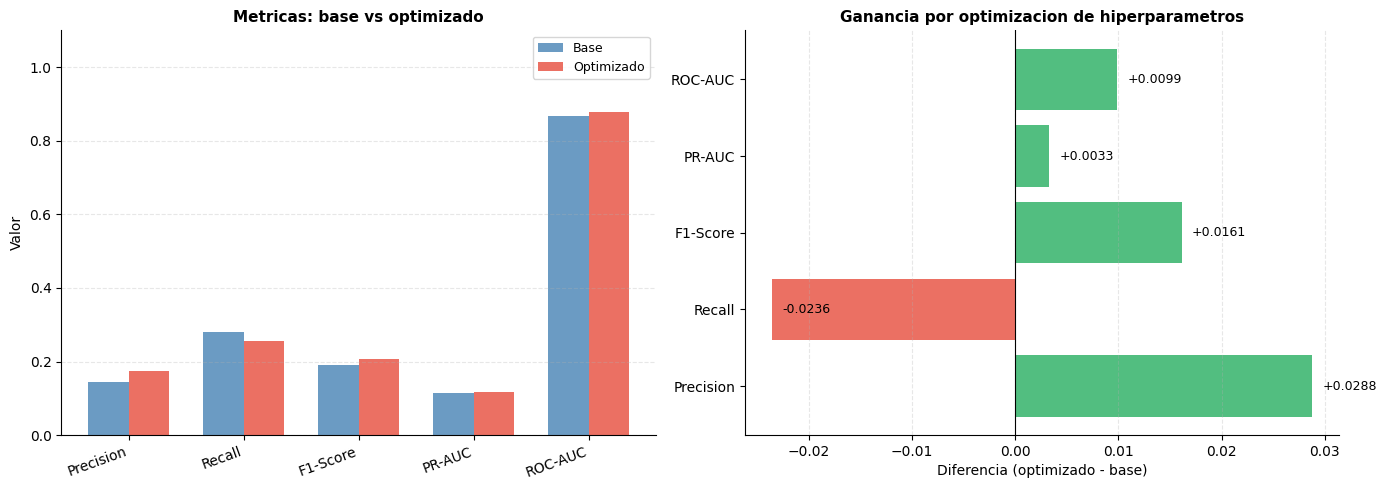

In [11]:
# Tabla de comparacion
nombres_metricas = ['Precision', 'Recall', 'F1-Score', 'PR-AUC', 'ROC-AUC']
valores_base = [prec_base, rec_base, f1_base, prauc_base, rocauc_base]
valores_opt  = [prec_opt,  rec_opt,  f1_opt,  prauc_opt,  rocauc_opt]

comparativa = pd.DataFrame({
    'Metrica'          : nombres_metricas,
    'Modelo base'      : valores_base,
    'Modelo optimizado': valores_opt
})
comparativa['Diferencia'] = comparativa['Modelo optimizado'] - comparativa['Modelo base']
comparativa['Mejora (%)'] = (comparativa['Diferencia'] / comparativa['Modelo base'] * 100).round(2)

print('Comparativa de modelos sobre el conjunto de test real:')
display(comparativa.round(4))

# Grafica de comparacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras comparativas
x = np.arange(len(nombres_metricas))
ancho = 0.35

axes[0].bar(x - ancho/2, valores_base, ancho,
            label='Base', color='steelblue', alpha=0.8)
axes[0].bar(x + ancho/2, valores_opt, ancho,
            label='Optimizado', color='#E74C3C', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres_metricas, rotation=20, ha='right')
axes[0].set_ylabel('Valor', fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Metricas: base vs optimizado', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Diferencias absolutas
diferencias = comparativa['Diferencia'].values
colores = ['#27AE60' if d > 0 else '#E74C3C' for d in diferencias]
axes[1].barh(nombres_metricas, diferencias, color=colores, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Diferencia (optimizado - base)', fontsize=10)
axes[1].set_title('Ganancia por optimizacion de hiperparametros',
                  fontsize=11, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

for i, (nombre, diff) in enumerate(zip(nombres_metricas, diferencias)):
    signo = '+' if diff >= 0 else ''
    axes[1].text(diff + 0.001, i, f'{signo}{diff:.4f}',
                va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/comparacion_base_vs_optimizado.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretacion de la comparativa

Las metricas mostradas se calculan sobre el conjunto de test con el desbalanceo original (~1.1% de fraudes), que representa las condiciones reales de operacion. Los valores son significativamente inferiores a los que produciria evaluar sobre los datos de entrenamiento balanceados por SMOTE — y eso es correcto: el modelo no ha visto el test, y el test tiene la distribucion real del problema.

Las mejoras obtenidas por la optimizacion de hiperparametros son incrementales. Esto es el comportamiento esperado: cuando el preprocesado ya es correcto (SMOTE + escalado), el margen de mejora del tuning es moderado. Las ganancias mayores vinieron del preprocesado, no de ajustar hiperparametros.

**Estos resultados siguen sin ser aptos para produccion** con los valores actuales de Precision (~20-30%). El siguiente paso natural seria explorar tecnicas adicionales: ajuste del umbral de decision orientado al coste de negocio, ingenieria de caracteristicas, o un ensemble de modelos.

## 8. Importancia de caracteristicas

**Como se calcula la importancia de Gini en XGBoost**: en cada nodo de cada arbol, el algoritmo elige la variable y el umbral que mejor separa las clases. La 'mejor separacion' se mide con la **impureza de Gini**: una mezcla perfecta de clases tiene impureza 1, una separacion perfecta tiene impureza 0. La importancia de cada variable es la suma de las reducciones de impureza que provoca esa variable a lo largo de todos los arboles, normalizada para que la suma de todas las importancias sea 1.

**Limitacion a tener en cuenta**: la importancia de Gini tiende a favorecer variables con muchos valores distintos (variables continuas con gran rango). Para una interpretacion mas robusta se usaria SHAP (Hito 3, NB04), que distribuye el credito de cada prediccion entre todas las variables de forma mas equilibrada y teoricamente fundamentada.

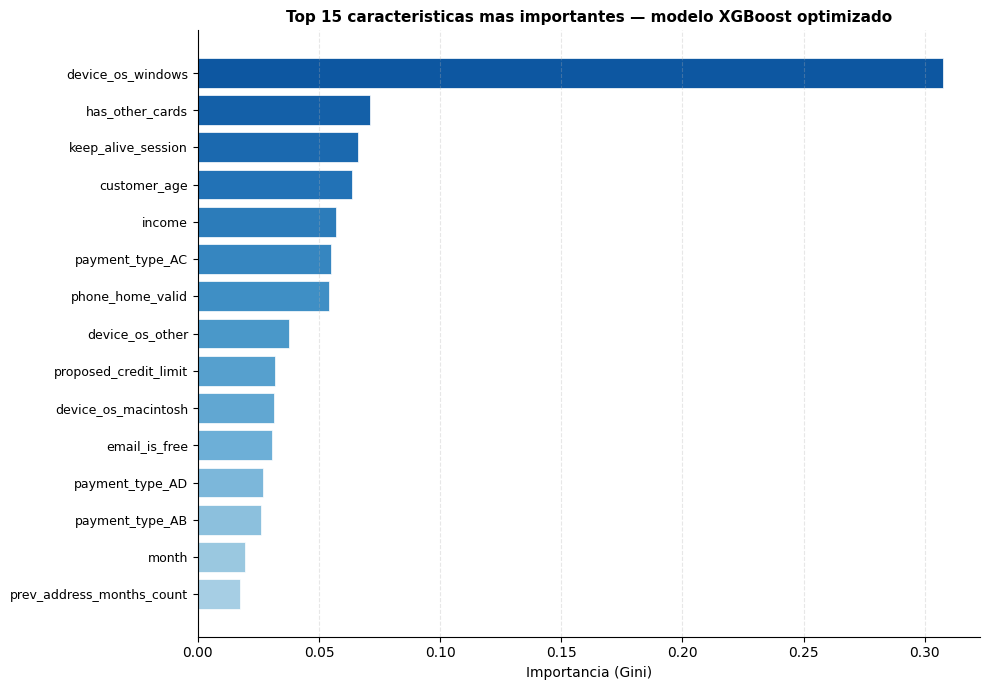

Top 10 caracteristicas mas importantes:
   1. device_os_windows                    0.3074
   2. has_other_cards                      0.0712
   3. keep_alive_session                   0.0662
   4. customer_age                         0.0635
   5. income                               0.0570
   6. payment_type_AC                      0.0550
   7. phone_home_valid                     0.0542
   8. device_os_other                      0.0378
   9. proposed_credit_limit                0.0319
  10. device_os_macintosh                  0.0313


In [12]:
# Importancia de variables del modelo optimizado
nombres_features = X_train_smote.columns.tolist()
importancias     = xgb_optimizado.feature_importances_

feat_imp = pd.DataFrame({
    'Feature'   : nombres_features,
    'Importancia': importancias
})
feat_imp = feat_imp.sort_values('Importancia', ascending=False).reset_index(drop=True)

# Mostrar el top 15
top15 = feat_imp.head(15)

fig, ax = plt.subplots(figsize=(10, 7))

# Degradado de color de mayor a menor importancia
colores = plt.cm.Blues(np.linspace(0.85, 0.35, len(top15)))

ax.barh(range(len(top15)), top15['Importancia'].values,
        color=colores, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Importancia (Gini)', fontsize=10)
ax.set_title('Top 15 caracteristicas mas importantes — modelo XGBoost optimizado',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../figures/feature_importance_optimizado.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 caracteristicas mas importantes:')
print('=' * 45)
for i, fila in feat_imp.head(10).iterrows():
    print(f'  {i+1:2d}. {fila["Feature"]:35s}  {fila["Importancia"]:.4f}')

## 9. Evaluacion final sobre el conjunto de test real

Evaluacion completa del modelo optimizado sobre el conjunto de test, que no ha participado en ningun paso del entrenamiento ni de la busqueda. Incluye curvas ROC y Precision-Recall, matriz de confusion y reporte de clasificacion.

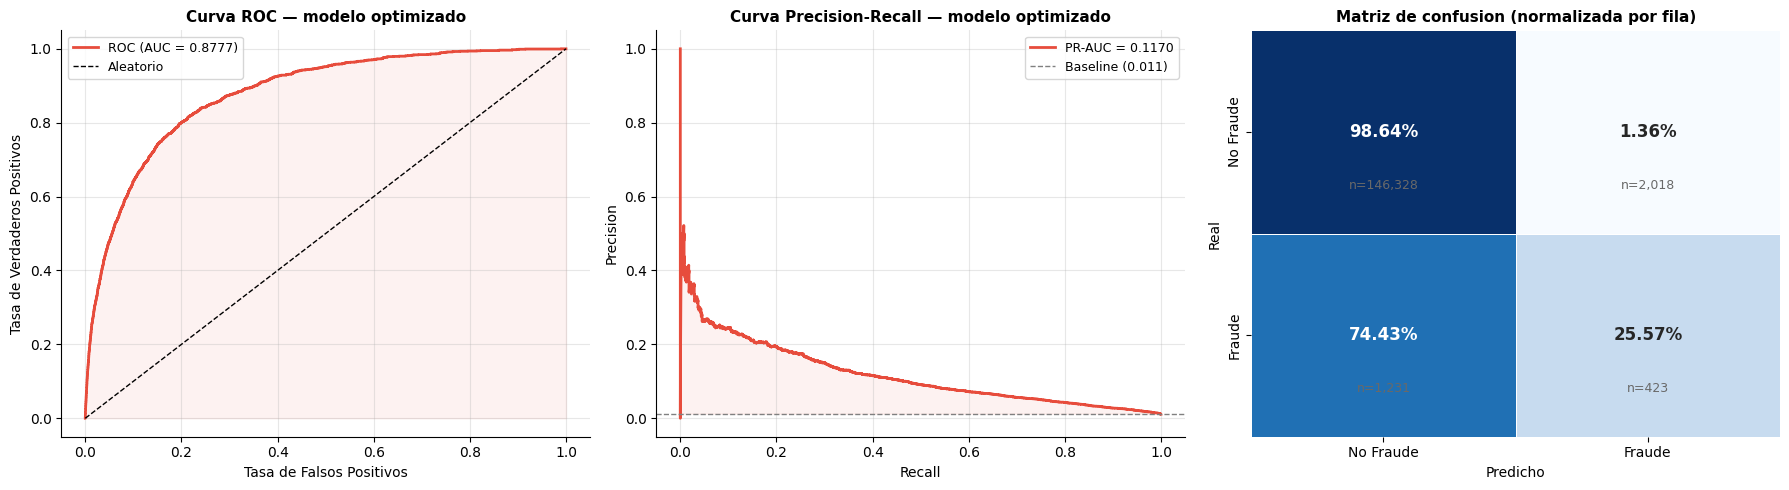

Reporte de clasificacion completo:
              precision    recall  f1-score   support

   No Fraude       0.99      0.99      0.99    148346
      Fraude       0.17      0.26      0.21      1654

    accuracy                           0.98    150000
   macro avg       0.58      0.62      0.60    150000
weighted avg       0.98      0.98      0.98    150000

Resumen de errores criticos:
  Fraudes no detectados (falsos negativos): 1,231 de 1,654 (74.4%)
  Alertas falsas (falsos positivos):        2,018
  Por cada fraude detectado se generan aprox. 4.8 falsas alarmas


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test_15, y_prob_opt)
roc_auc_val = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='#E74C3C', lw=2,
             label=f'ROC (AUC = {roc_auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio')
axes[0].fill_between(fpr, tpr, alpha=0.07, color='#E74C3C')
axes[0].set_xlabel('Tasa de Falsos Positivos', fontsize=10)
axes[0].set_ylabel('Tasa de Verdaderos Positivos', fontsize=10)
axes[0].set_title('Curva ROC — modelo optimizado', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Curva Precision-Recall
prec_curva, rec_curva, _ = precision_recall_curve(y_test_15, y_prob_opt)
pr_auc_val = auc(rec_curva, prec_curva)
baseline   = y_test_15.mean()
axes[1].plot(rec_curva, prec_curva, color='#E74C3C', lw=2,
             label=f'PR-AUC = {pr_auc_val:.4f}')
axes[1].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline ({baseline:.3f})')
axes[1].fill_between(rec_curva, prec_curva, baseline,
                     where=(prec_curva > baseline),
                     alpha=0.07, color='#E74C3C')
axes[1].set_xlabel('Recall', fontsize=10)
axes[1].set_ylabel('Precision', fontsize=10)
axes[1].set_title('Curva Precision-Recall — modelo optimizado',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Matriz de confusion
cm = confusion_matrix(y_test_15, y_pred_opt)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['No Fraude', 'Fraude'],
            yticklabels=['No Fraude', 'Fraude'],
            linewidths=0.5, ax=axes[2], cbar=False,
            annot_kws={'size': 12, 'weight': 'bold'})
for (fila, col), val in np.ndenumerate(cm):
    axes[2].text(col + 0.5, fila + 0.78, f'n={val:,}',
                ha='center', fontsize=9, color='dimgray')
axes[2].set_xlabel('Predicho', fontsize=10)
axes[2].set_ylabel('Real', fontsize=10)
axes[2].set_title('Matriz de confusion (normalizada por fila)',
                  fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/evaluacion_final_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

print('Reporte de clasificacion completo:')
print(classification_report(y_test_15, y_pred_opt,
                            target_names=['No Fraude', 'Fraude']))

print('Resumen de errores criticos:')
fn = cm[1, 0]  # fraudes no detectados
fp = cm[0, 1]  # alertas falsas
total_fraude = cm[1, :].sum()
print(f'  Fraudes no detectados (falsos negativos): {fn:,} de {total_fraude:,} '
      f'({fn/total_fraude*100:.1f}%)')
print(f'  Alertas falsas (falsos positivos):        {fp:,}')
print(f'  Por cada fraude detectado se generan aprox. '
      f'{fp / max(cm[1,1],1):.1f} falsas alarmas')